# 05 - Probability Calibration and Calibrated Score

A credit score is built from default probabilities, so the probabilities should be reliable. In this notebook, we compare raw and calibrated models before rebuilding the score.

## 1. Setup

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_default.config import MODELS_DIR, PROCESSED_DATA_DIR, TABLES_DIR  # noqa: E402
from credit_default.data import TARGET_COLUMN, load_credit_data  # noqa: E402
from credit_default.modeling import (  # noqa: E402
    RANDOM_STATE,
    binary_classification_metrics,
    build_pipeline,
    calibration_bin_table,
    expected_calibration_error,
    load_modeling_base,
    positive_class_scores,
    split_features_target,
)
from credit_default.preprocessing import (  # noqa: E402
    MODEL_CATEGORICAL_COLUMNS,
    MODEL_NUMERIC_COLUMNS,
    build_modeling_base,
)
from credit_default.scoring import (  # noqa: E402
    assign_credit_decision,
    assign_score_bands,
    build_score_scale,
    fit_score_band_edges,
    probability_to_score,
    summarize_by_group,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/chris/OneDrive/Dokumente/projet/credit client')

## 2. Data and Splits

We use separate train, calibration, validation, and test sets. The calibration set is only used to learn the probability mapping.

In [3]:
modeling_path = PROCESSED_DATA_DIR / "credit_default_modeling_base.csv"

if modeling_path.exists():
    modeling = load_modeling_base(modeling_path)
else:
    raw = load_credit_data()
    modeling = build_modeling_base(raw)
    modeling.to_csv(modeling_path, index=False)

X, y = split_features_target(modeling)

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train_cal, X_valid, y_train_cal, y_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.15 / 0.85,
    stratify=y_dev,
    random_state=RANDOM_STATE,
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal,
    y_train_cal,
    test_size=0.15 / 0.70,
    stratify=y_train_cal,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(y_train), "default_rate": y_train.mean()},
        {"split": "calibration", "rows": len(y_cal), "default_rate": y_cal.mean()},
        {"split": "validation", "rows": len(y_valid), "default_rate": y_valid.mean()},
        {"split": "test", "rows": len(y_test), "default_rate": y_test.mean()},
    ]
)
display(split_summary)

,split,rows,default_rate
0,train,16500,0.2212
1,calibration,4500,0.2213
2,validation,4500,0.2211
3,test,4500,0.2211


## 3. Calibration Candidates

We compare logistic regression, LightGBM, CatBoost, and sigmoid/isotonic calibration variants. CatBoost is fitted directly on the modeling table so it can use categorical variables without one-hot encoding.

In [4]:
def positive_class_weight(y_values: pd.Series) -> float:
    negatives = (y_values == 0).sum()
    positives = (y_values == 1).sum()
    return negatives / positives


def make_lightgbm(class_weight=None):
    return LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=40,
        reg_lambda=5.0,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def make_catboost(auto_class_weights: str | None = None):
    return CatBoostClassifier(
        iterations=500,
        learning_rate=0.035,
        depth=5,
        l2_leaf_reg=5.0,
        random_strength=1.0,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights=auto_class_weights,
        cat_features=MODEL_CATEGORICAL_COLUMNS,
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
    )


base_specs = [
    {
        "name": "logistic_l2_raw",
        "model_family": "linear",
        "scale_numeric": True,
        "direct_categorical": False,
        "estimator": LogisticRegression(max_iter=2_000, solver="lbfgs", n_jobs=-1),
        "calibration": "none",
    },
    {
        "name": "lightgbm_unweighted_raw",
        "model_family": "boosting",
        "scale_numeric": False,
        "direct_categorical": False,
        "estimator": make_lightgbm(class_weight=None),
        "calibration": "none",
    },
    {
        "name": "lightgbm_balanced_raw",
        "model_family": "boosting",
        "scale_numeric": False,
        "direct_categorical": False,
        "estimator": make_lightgbm(class_weight="balanced"),
        "calibration": "none",
    },
    {
        "name": "catboost_plain_raw",
        "model_family": "boosting",
        "scale_numeric": False,
        "direct_categorical": True,
        "estimator": make_catboost(auto_class_weights=None),
        "calibration": "none",
    },
    {
        "name": "catboost_balanced_raw",
        "model_family": "boosting",
        "scale_numeric": False,
        "direct_categorical": True,
        "estimator": make_catboost(auto_class_weights="Balanced"),
        "calibration": "none",
    },
    {
        "name": "catboost_sqrt_balanced_raw",
        "model_family": "boosting",
        "scale_numeric": False,
        "direct_categorical": True,
        "estimator": make_catboost(auto_class_weights="SqrtBalanced"),
        "calibration": "none",
    },
]


def fit_base_candidate(spec: dict, X_fit: pd.DataFrame, y_fit: pd.Series):
    if spec.get("direct_categorical", False):
        model = spec["estimator"]
    else:
        model = build_pipeline(spec["estimator"], scale_numeric=spec["scale_numeric"])
    model.fit(X_fit, y_fit)
    return model


display(pd.DataFrame([{k: v for k, v in spec.items() if k != "estimator"} for spec in base_specs]))

,name,model_family,scale_numeric,direct_categorical,calibration
0,logistic_l2_raw,linear,True,False,none
1,lightgbm_unweighted_raw,boosting,False,False,none
2,lightgbm_balanced_raw,boosting,False,False,none
3,catboost_plain_raw,boosting,False,True,none
4,catboost_balanced_raw,boosting,False,True,none
5,catboost_sqrt_balanced_raw,boosting,False,True,none


## 4. Fit, Calibrate, and Compare

Brier score and expected calibration error measure probability quality. PR-AUC and ROC-AUC are monitored to avoid sacrificing ranking performance.

In [5]:
fitted_candidates = {}
validation_rows = []

for spec in base_specs:
    base_name = spec["name"]
    start = time.perf_counter()
    base_model = fit_base_candidate(spec, X_train, y_train)
    fit_seconds = time.perf_counter() - start

    fitted_candidates[base_name] = base_model
    valid_scores = positive_class_scores(base_model, X_valid)
    metrics = binary_classification_metrics(y_valid, valid_scores, threshold=0.5)
    validation_rows.append(
        {
            "candidate": base_name,
            "base_model": base_name,
            "model_family": spec["model_family"],
            "calibration": "none",
            "fit_seconds": fit_seconds,
            "expected_calibration_error": expected_calibration_error(y_valid, valid_scores),
            **metrics,
        }
    )

    if spec["model_family"] == "boosting":
        for method in ["sigmoid", "isotonic"]:
            candidate_name = f"{base_name.replace('_raw', '')}_{method}"
            start = time.perf_counter()
            calibrated_model = CalibratedClassifierCV(
                estimator=FrozenEstimator(base_model),
                method=method,
            )
            calibrated_model.fit(X_cal, y_cal)
            calibration_seconds = time.perf_counter() - start

            fitted_candidates[candidate_name] = calibrated_model
            valid_scores = positive_class_scores(calibrated_model, X_valid)
            metrics = binary_classification_metrics(y_valid, valid_scores, threshold=0.5)
            validation_rows.append(
                {
                    "candidate": candidate_name,
                    "base_model": base_name,
                    "model_family": spec["model_family"],
                    "calibration": method,
                    "fit_seconds": fit_seconds + calibration_seconds,
                    "expected_calibration_error": expected_calibration_error(y_valid, valid_scores),
                    **metrics,
                }
            )

calibration_validation_metrics = (
    pd.DataFrame(validation_rows)
    .sort_values(
        ["brier_score", "expected_calibration_error", "pr_auc"],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

display(calibration_validation_metrics)

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-pac

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-pac

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,candidate,base_model,model_family,calibration,fit_seconds,expected_calibration_error,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1
0,catboost_sqrt_balanced_sigmoid,catboost_sqrt_balanced_raw,boosting,sigmoid,19.5789,0.0154,0.5000,0.7922,0.5750,0.1311,0.8276,0.6727,0.6931,0.3950,0.5032
1,catboost_plain_raw,catboost_plain_raw,boosting,none,19.4210,0.0109,0.5000,0.7925,0.5775,0.1312,0.8256,0.6577,0.7100,0.3568,0.4749
2,catboost_plain_isotonic,catboost_plain_raw,boosting,isotonic,19.4531,0.0147,0.5000,0.7919,0.5591,0.1314,0.8260,0.6717,0.6847,0.3950,0.5010
3,catboost_sqrt_balanced_isotonic,catboost_sqrt_balanced_raw,boosting,isotonic,19.5755,0.0128,0.5000,0.7909,0.5525,0.1315,0.8269,0.6604,0.7143,0.3618,0.4803
4,catboost_balanced_sigmoid,catboost_balanced_raw,boosting,sigmoid,19.1508,0.0210,0.5000,0.7917,0.5716,0.1318,0.8269,0.6751,0.6843,0.4030,0.5073
5,catboost_plain_sigmoid,catboost_plain_raw,boosting,sigmoid,19.4542,0.0253,0.5000,0.7925,0.5775,0.1319,0.8256,0.6573,0.7108,0.3558,0.4742
6,lightgbm_balanced_isotonic,lightgbm_balanced_raw,boosting,isotonic,1.1285,0.0224,0.5000,0.7856,0.5560,0.1320,0.8276,0.6734,0.6918,0.3970,0.5045
7,catboost_balanced_isotonic,catboost_balanced_raw,boosting,isotonic,19.1487,0.0173,0.5000,0.7900,0.5523,0.1321,0.8273,0.6621,0.7137,0.3658,0.4837
8,lightgbm_balanced_sigmoid,lightgbm_balanced_raw,boosting,sigmoid,1.1296,0.0267,0.5000,0.7868,0.5724,0.1323,0.8289,0.6768,0.6943,0.4040,0.5108
9,logistic_l2_raw,logistic_l2_raw,linear,none,0.3209,0.0129,0.5000,0.7805,0.5656,0.1329,0.8258,0.6575,0.7123,0.3558,0.4745


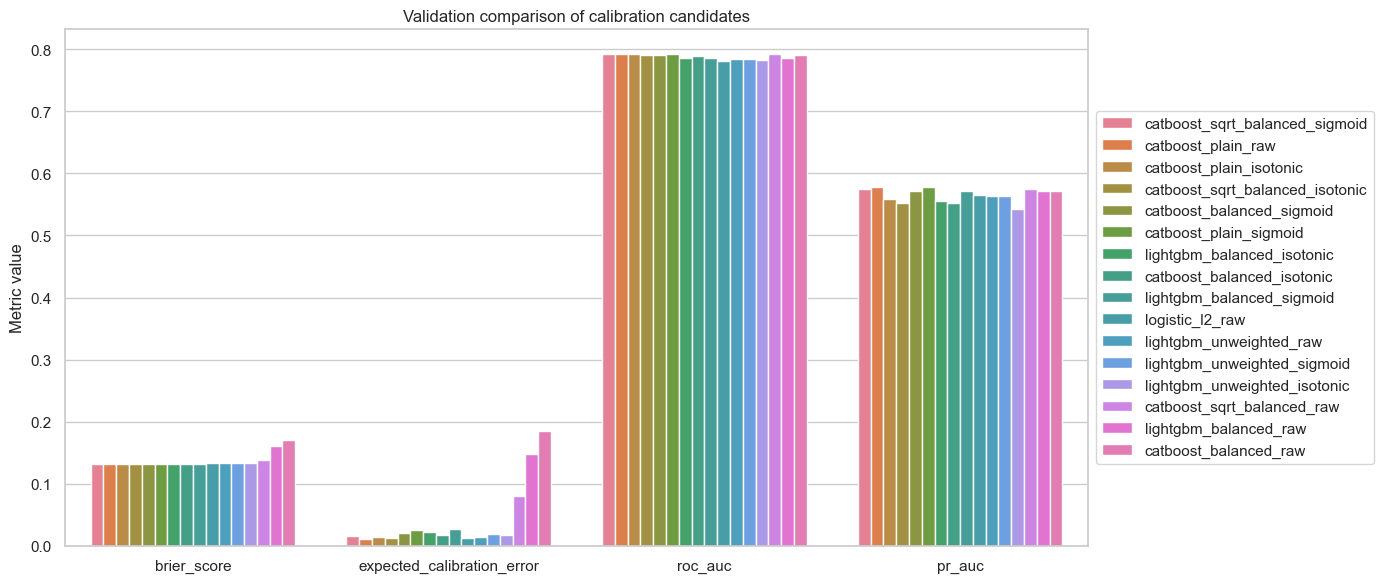

In [6]:
plot_metrics = calibration_validation_metrics.melt(
    id_vars=["candidate", "calibration"],
    value_vars=["brier_score", "expected_calibration_error", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_metrics, x="metric", y="value", hue="candidate", ax=ax)
ax.set_title("Validation comparison of calibration candidates")
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-pac

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


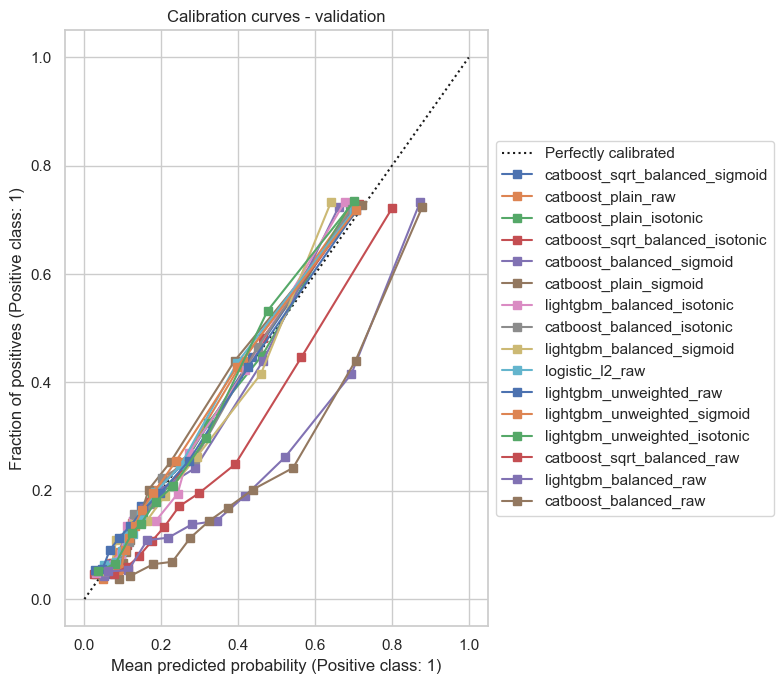

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
for candidate in calibration_validation_metrics["candidate"]:
    estimator = fitted_candidates[candidate]
    CalibrationDisplay.from_estimator(
        estimator,
        X_valid,
        y_valid,
        n_bins=10,
        strategy="quantile",
        name=candidate,
        ax=ax,
    )
ax.set_title("Calibration curves - validation")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 5. Selection and Test Evaluation

Candidates with similar Brier scores are compared by PR-AUC and calibration error. The selected candidate is then evaluated on the test set.

In [8]:
best_brier = calibration_validation_metrics["brier_score"].min()
brier_tolerance = 0.001
eligible_candidates = calibration_validation_metrics[
    calibration_validation_metrics["brier_score"] <= best_brier + brier_tolerance
].copy()
eligible_candidates = eligible_candidates.sort_values(
    ["pr_auc", "expected_calibration_error", "brier_score"],
    ascending=[False, True, True],
)
best_candidate = eligible_candidates.iloc[0]["candidate"]
best_calibrated_model = fitted_candidates[best_candidate]

valid_scores = positive_class_scores(best_calibrated_model, X_valid)
test_scores = positive_class_scores(best_calibrated_model, X_test)

best_valid_calibration_table = calibration_bin_table(y_valid, valid_scores)
best_test_calibration_table = calibration_bin_table(y_test, test_scores)

calibration_test_metrics = pd.DataFrame(
    [
        {
            "candidate": best_candidate,
            "split": "validation",
            "expected_calibration_error": expected_calibration_error(y_valid, valid_scores),
            **binary_classification_metrics(y_valid, valid_scores, threshold=0.5),
        },
        {
            "candidate": best_candidate,
            "split": "test",
            "expected_calibration_error": expected_calibration_error(y_test, test_scores),
            **binary_classification_metrics(y_test, test_scores, threshold=0.5),
        },
    ]
)

print(f"Best Brier score on validation: {best_brier:.6f}")
print(f"Brier tolerance for score usability: {brier_tolerance:.6f}")
print(f"Best score candidate: {best_candidate}")
display(eligible_candidates)
display(calibration_test_metrics)
display(best_test_calibration_table)

Best Brier score on validation: 0.131146
Brier tolerance for score usability: 0.001000
Best score candidate: catboost_plain_raw


,candidate,base_model,model_family,calibration,fit_seconds,expected_calibration_error,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1
1,catboost_plain_raw,catboost_plain_raw,boosting,none,19.4210,0.0109,0.5000,0.7925,0.5775,0.1312,0.8256,0.6577,0.7100,0.3568,0.4749
5,catboost_plain_sigmoid,catboost_plain_raw,boosting,sigmoid,19.4542,0.0253,0.5000,0.7925,0.5775,0.1319,0.8256,0.6573,0.7108,0.3558,0.4742
0,catboost_sqrt_balanced_sigmoid,catboost_sqrt_balanced_raw,boosting,sigmoid,19.5789,0.0154,0.5000,0.7922,0.5750,0.1311,0.8276,0.6727,0.6931,0.3950,0.5032
4,catboost_balanced_sigmoid,catboost_balanced_raw,boosting,sigmoid,19.1508,0.0210,0.5000,0.7917,0.5716,0.1318,0.8269,0.6751,0.6843,0.4030,0.5073
2,catboost_plain_isotonic,catboost_plain_raw,boosting,isotonic,19.4531,0.0147,0.5000,0.7919,0.5591,0.1314,0.8260,0.6717,0.6847,0.3950,0.5010
6,lightgbm_balanced_isotonic,lightgbm_balanced_raw,boosting,isotonic,1.1285,0.0224,0.5000,0.7856,0.5560,0.1320,0.8276,0.6734,0.6918,0.3970,0.5045
3,catboost_sqrt_balanced_isotonic,catboost_sqrt_balanced_raw,boosting,isotonic,19.5755,0.0128,0.5000,0.7909,0.5525,0.1315,0.8269,0.6604,0.7143,0.3618,0.4803
7,catboost_balanced_isotonic,catboost_balanced_raw,boosting,isotonic,19.1487,0.0173,0.5000,0.7900,0.5523,0.1321,0.8273,0.6621,0.7137,0.3658,0.4837


,candidate,split,expected_calibration_error,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1
0,catboost_plain_raw,validation,0.0109,0.5000,0.7925,0.5775,0.1312,0.8256,0.6577,0.7100,0.3568,0.4749
1,catboost_plain_raw,test,0.0091,0.5000,0.7905,0.5772,0.1324,0.8218,0.6549,0.6874,0.3558,0.4689


,bin,n,mean_predicted_default_probability,observed_default_rate,abs_calibration_error,weighted_abs_calibration_error
0,"(0.0242, 0.0603]",450,0.0470,0.0378,0.0092,0.0009
1,"(0.0603, 0.0794]",450,0.0698,0.0644,0.0054,0.0005
2,"(0.0794, 0.0986]",450,0.0889,0.0889,0.0001,0.0000
3,"(0.0986, 0.118]",450,0.1079,0.1000,0.0079,0.0008
4,"(0.118, 0.138]",450,0.1277,0.1378,0.0101,0.0010
5,"(0.138, 0.166]",450,0.1514,0.1644,0.0130,0.0013
6,"(0.166, 0.218]",450,0.1893,0.2067,0.0174,0.0017
7,"(0.218, 0.326]",450,0.2645,0.2756,0.0111,0.0011
8,"(0.326, 0.569]",450,0.4218,0.4311,0.0093,0.0009
9,"(0.569, 0.901]",450,0.7119,0.7044,0.0074,0.0007


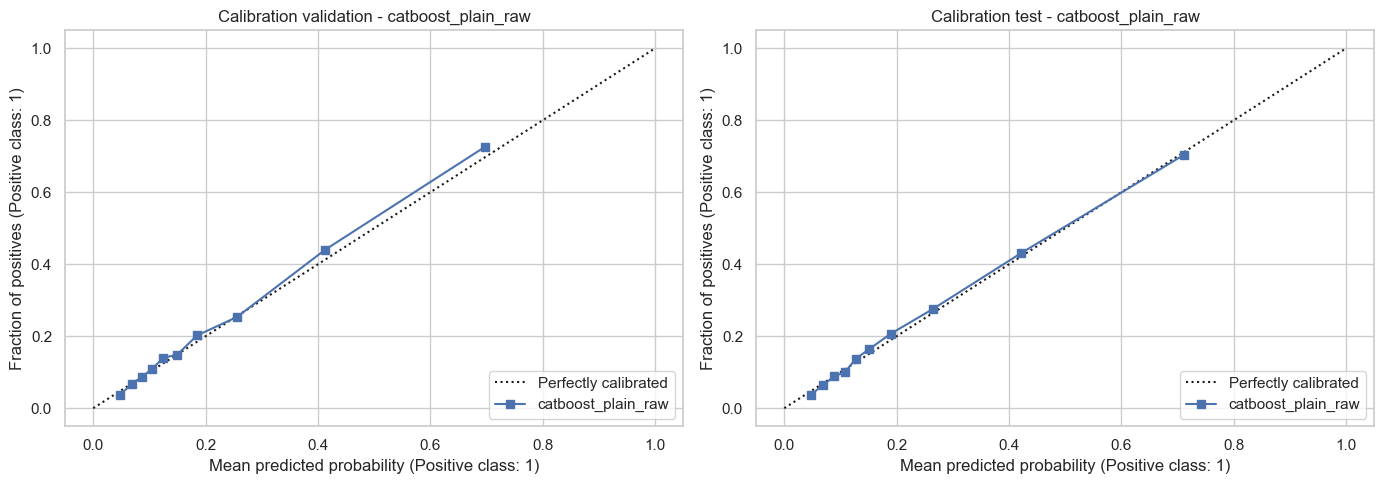

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split_name, split_X, split_y, axis in [
    ("validation", X_valid, y_valid, axes[0]),
    ("test", X_test, y_test, axes[1]),
]:
    CalibrationDisplay.from_estimator(
        best_calibrated_model,
        split_X,
        split_y,
        n_bins=10,
        strategy="quantile",
        name=best_candidate,
        ax=axis,
    )
    axis.set_title(f"Calibration {split_name} - {best_candidate}")

plt.tight_layout()
plt.show()

## 6. Rebuild the Calibrated Score

The selected calibrated probabilities are converted into a score. Score bands are fitted on development data and evaluated on the test set.

In [10]:
all_scores = positive_class_scores(best_calibrated_model, X)
score_scale = build_score_scale(base_default_rate=y_train.mean())

scored_calibrated = pd.DataFrame(
    {
        "ID": modeling["ID"],
        "calibrated_default_probability": all_scores,
        "calibrated_credit_score": probability_to_score(all_scores, score_scale).round(0).astype(int),
        TARGET_COLUMN: modeling[TARGET_COLUMN],
    },
    index=modeling.index,
)

score_band_reference_index = y_train.index.union(y_cal.index).union(y_valid.index)
band_edges = fit_score_band_edges(scored_calibrated.loc[score_band_reference_index, "calibrated_credit_score"])
scored_calibrated["calibrated_risk_band"] = assign_score_bands(
    scored_calibrated["calibrated_credit_score"],
    band_edges,
)
scored_calibrated["calibrated_credit_decision"] = assign_credit_decision(
    scored_calibrated["calibrated_risk_band"]
)

score_summary = scored_calibrated[["calibrated_default_probability", "calibrated_credit_score"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(score_summary)
display(scored_calibrated.head())

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
calibrated_default_probability,"30,000.0000",0.2187,0.1983,0.0211,0.0360,0.0484,0.0592,0.0877,0.1389,0.2641,0.5630,0.7088,0.8182,0.9310
calibrated_credit_score,"30,000.0000",621.4128,81.4641,322.0000,401.0000,445.0000,491.0000,583.0000,641.0000,678.0000,709.0000,724.0000,746.0000,786.0000


,ID,calibrated_default_probability,calibrated_credit_score,default_payment_next_month,calibrated_risk_band,calibrated_credit_decision
0,1,0.7808,418,1,E_very_high_risk,reject
1,2,0.3120,566,1,D_high_risk,manual_review
2,3,0.0887,677,0,B_low_risk,approve
3,4,0.1517,633,0,C_medium_risk,approve
4,5,0.0834,682,0,B_low_risk,approve


In [11]:
test_scored_calibrated = scored_calibrated.loc[y_test.index].copy()

test_band_summary = summarize_by_group(
    test_scored_calibrated.rename(
        columns={
            "calibrated_risk_band": "risk_band",
            "calibrated_credit_score": "credit_score",
            "calibrated_default_probability": "predicted_default_probability",
        }
    ),
    "risk_band",
    target_col=TARGET_COLUMN,
).sort_values("mean_credit_score")

policy_summary = summarize_by_group(
    test_scored_calibrated.rename(
        columns={
            "calibrated_credit_decision": "credit_decision",
            "calibrated_credit_score": "credit_score",
            "calibrated_default_probability": "predicted_default_probability",
        }
    ),
    "credit_decision",
    target_col=TARGET_COLUMN,
).sort_values("observed_default_rate")

display(test_band_summary)
display(policy_summary)

,risk_band,n,observed_defaults,observed_default_rate,mean_predicted_default_probability,mean_credit_score,min_credit_score,max_credit_score,share
0,E_very_high_risk,889,507,0.5703,0.5698,485.9044,350,560,0.1976
1,D_high_risk,883,216,0.2446,0.2300,597.5934,561,624,0.1962
2,C_medium_risk,961,147,0.1530,0.1396,640.8200,625,655,0.2136
3,B_low_risk,910,83,0.0912,0.0968,670.7835,656,687,0.2022
4,A_very_low_risk,857,42,0.0490,0.0574,713.2287,688,773,0.1904


,credit_decision,n,observed_defaults,observed_default_rate,mean_predicted_default_probability,mean_credit_score,min_credit_score,max_credit_score,share
0,approve,2728,272,0.0997,0.0995,673.5623,625,773,0.6062
1,manual_review,883,216,0.2446,0.2300,597.5934,561,624,0.1962
2,reject,889,507,0.5703,0.5698,485.9044,350,560,0.1976


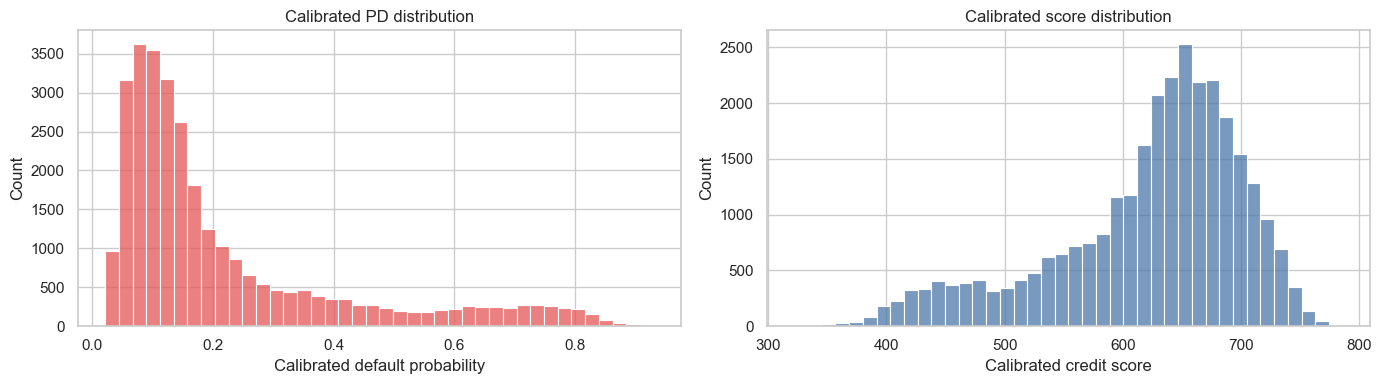

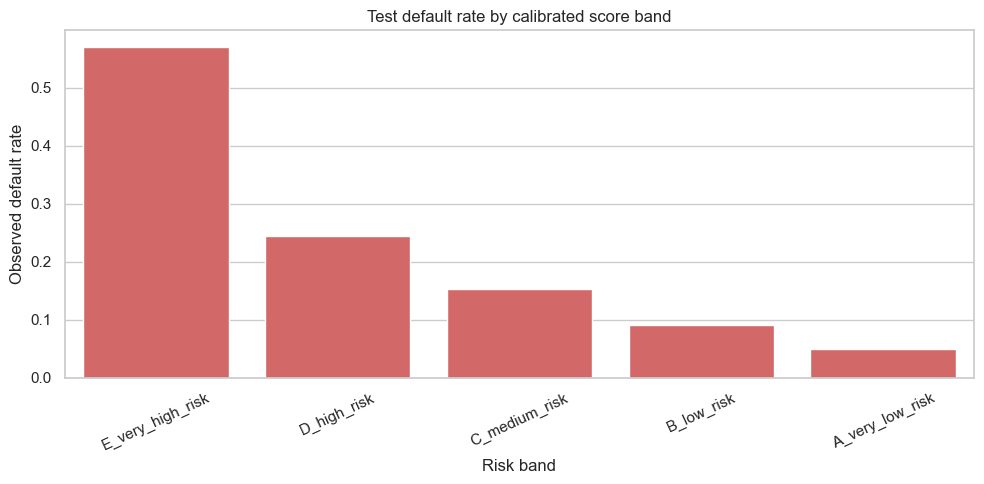

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(scored_calibrated["calibrated_default_probability"], bins=40, color="#E45756", ax=axes[0])
axes[0].set_title("Calibrated PD distribution")
axes[0].set_xlabel("Calibrated default probability")

sns.histplot(scored_calibrated["calibrated_credit_score"], bins=40, color="#4C78A8", ax=axes[1])
axes[1].set_title("Calibrated score distribution")
axes[1].set_xlabel("Calibrated credit score")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=test_band_summary, x="risk_band", y="observed_default_rate", color="#E45756", ax=ax)
ax.set_title("Test default rate by calibrated score band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Observed default rate")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 7. Exports

The calibrated model, scored client file, score scale, band summaries, and calibration metrics are saved for reporting.

In [13]:
calibration_validation_metrics_path = TABLES_DIR / "calibration_validation_metrics.csv"
calibration_test_metrics_path = TABLES_DIR / "calibration_test_metrics.csv"
calibration_bins_test_path = TABLES_DIR / "calibration_test_bins.csv"
calibrated_score_scale_path = TABLES_DIR / "calibrated_credit_score_scale.csv"
calibrated_band_summary_path = TABLES_DIR / "calibrated_credit_score_test_band_summary.csv"
calibrated_policy_summary_path = TABLES_DIR / "calibrated_credit_score_test_policy_summary.csv"
calibrated_scored_path = PROCESSED_DATA_DIR / "credit_default_scored_calibrated.csv"
calibrated_model_path = MODELS_DIR / "best_calibrated_score_model.joblib"

calibration_validation_metrics.to_csv(calibration_validation_metrics_path, index=False)
calibration_test_metrics.to_csv(calibration_test_metrics_path, index=False)
best_test_calibration_table.to_csv(calibration_bins_test_path, index=False)
pd.DataFrame([score_scale]).to_csv(calibrated_score_scale_path, index=False)
test_band_summary.to_csv(calibrated_band_summary_path, index=False)
policy_summary.to_csv(calibrated_policy_summary_path, index=False)
scored_calibrated.reset_index(drop=True).to_csv(calibrated_scored_path, index=False)
joblib.dump(
    {
        "candidate": best_candidate,
        "pipeline": best_calibrated_model,
        "score_scale": score_scale,
        "band_edges": band_edges,
        "numeric_columns": MODEL_NUMERIC_COLUMNS,
        "categorical_columns": MODEL_CATEGORICAL_COLUMNS,
    },
    calibrated_model_path,
)

exports = pd.DataFrame(
    [
        {"artifact": "calibration validation metrics", "path": calibration_validation_metrics_path.relative_to(PROJECT_ROOT)},
        {"artifact": "calibration test metrics", "path": calibration_test_metrics_path.relative_to(PROJECT_ROOT)},
        {"artifact": "calibration test bins", "path": calibration_bins_test_path.relative_to(PROJECT_ROOT)},
        {"artifact": "calibrated score scale", "path": calibrated_score_scale_path.relative_to(PROJECT_ROOT)},
        {"artifact": "test band summary", "path": calibrated_band_summary_path.relative_to(PROJECT_ROOT)},
        {"artifact": "test policy summary", "path": calibrated_policy_summary_path.relative_to(PROJECT_ROOT)},
        {"artifact": "calibrated scored clients", "path": calibrated_scored_path.relative_to(PROJECT_ROOT)},
        {"artifact": "calibrated model", "path": calibrated_model_path.relative_to(PROJECT_ROOT)},
    ]
)
display(exports)

,artifact,path
0,calibration validation metrics,reports\tables\calibration_validation_metrics.csv
1,calibration test metrics,reports\tables\calibration_test_metrics.csv
2,calibration test bins,reports\tables\calibration_test_bins.csv
3,calibrated score scale,reports\tables\calibrated_credit_score_scale.csv
4,test band summary,reports\tables\calibrated_credit_score_test_ba...
5,test policy summary,reports\tables\calibrated_credit_score_test_po...
6,calibrated scored clients,data\processed\credit_default_scored_calibrate...
7,calibrated model,models\best_calibrated_score_model.joblib


## 8. Summary

Calibration makes the scoring output more reliable by aligning predicted default probabilities with observed default rates.